# Asssignment 1

Question 10

In [5]:
import numpy as np

prices = np.array([
    [100, 108, 103, 115, 110, 119, 125, 121, 130, 127, 135, 140],   # Stock A
    [200, 195, 210, 205, 220, 215, 225, 230, 222, 235, 240, 238]    # Stock B
])


returns = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1]

print("Monthly Returns:\n")
print(returns)

print("\nShape of returns array:")
print(returns.shape)


monthly_mean = np.mean(returns, axis=1)

monthly_std = np.std(returns, axis=1, ddof=1)

annualised_mean = monthly_mean * 12

annualised_std = monthly_std * np.sqrt(12)

print("\nAnnualised Mean Returns:")
print(annualised_mean)

print("\nAnnualised Standard Deviations:")
print(annualised_std)


cov_matrix = np.cov(returns)

print("\nCovariance Matrix:")
print(cov_matrix)


corr = np.corrcoef(returns)[0, 1]

sigma_A = np.std(returns[0], ddof=1)

sigma_B = np.std(returns[1], ddof=1)

check_value = corr * sigma_A * sigma_B

print("\nOff-diagonal covariance value:")
print(cov_matrix[0, 1])

print("\nρ × σA × σB:")
print(check_value)


Monthly Returns:

[[ 0.08       -0.0462963   0.11650485 -0.04347826  0.08181818  0.05042017
  -0.032       0.07438017 -0.02307692  0.06299213  0.03703704]
 [-0.025       0.07692308 -0.02380952  0.07317073 -0.02272727  0.04651163
   0.02222222 -0.03478261  0.05855856  0.0212766  -0.00833333]]

Shape of returns array:
(2, 11)

Annualised Mean Returns:
[0.39087388 0.20073826]

Annualised Standard Deviations:
[0.20199403 0.14582022]

Covariance Matrix:
[[ 0.00340013 -0.00206426]
 [-0.00206426  0.00177196]]

Off-diagonal covariance value:
-0.0020642605060094284

ρ × σA × σB:
-0.0020642605060094284


Question 11

In [6]:
import numpy as np

mu = np.array([0.15, 0.08, 0.05])

Sigma = np.array([
    [0.0625, 0.012,   0.001],
    [0.012,  0.0144,  0.00096],
    [0.001,  0.00096, 0.0016]
])


w = np.array([1/3, 1/3, 1/3])


portfolio_return = w @ mu


portfolio_variance = w @ Sigma @ w

print("Expected Portfolio Return:")
print(portfolio_return)

print("\nPortfolio Variance:")
print(portfolio_variance)


np.random.seed(0)

weights = np.random.dirichlet(np.ones(3), size=10000)


portfolio_returns = weights @ mu


portfolio_variances = np.sum((weights @ Sigma) * weights, axis=1)


portfolio_std = np.sqrt(portfolio_variances)

print("\nShape of Portfolio Returns:")
print(portfolio_returns.shape)

print("\nShape of Portfolio Standard Deviations:")
print(portfolio_std.shape)


Rf = 0.04

sharpe_ratios = (portfolio_returns - Rf) / portfolio_std


max_index = np.argmax(sharpe_ratios)

max_sharpe = sharpe_ratios[max_index]

best_weights = weights[max_index]

print("\nMaximum Sharpe Ratio:")
print(max_sharpe)

print("\nWeights of Maximum Sharpe Portfolio:")
print(best_weights)


Expected Portfolio Return:
0.09333333333333332

Portfolio Variance:
0.011824444444444443

Shape of Portfolio Returns:
(10000,)

Shape of Portfolio Standard Deviations:
(10000,)

Maximum Sharpe Ratio:
0.5053304663530758

Weights of Maximum Sharpe Portfolio:
[0.19855292 0.17153581 0.62991127]


Question 12

In [7]:
import numpy as np

mu1 = 0.12
sigma1 = 0.20

mu2 = 0.06
sigma2 = 0.10

w1 = 0.6
w2 = 1 - w1

rho = np.linspace(-1, 1, 200)

portfolio_variance = (
    (w1**2) * (sigma1**2)
    + (w2**2) * (sigma2**2)
    + 2 * w1 * w2 * rho * sigma1 * sigma2
)
portfolio_std = np.sqrt(portfolio_variance)

print("Portfolio Standard Deviations:\n")
print(portfolio_std)

print("\nShape of Portfolio Std Array:")
print(portfolio_std.shape)

min_index = np.argmin(portfolio_std)

min_risk = portfolio_std[min_index]

min_rho = rho[min_index]

print("\nMinimum Portfolio Risk:")
print(min_risk)

print("\nCorrelation at Minimum Risk:")
print(min_rho)

print("\nAnalytical Verification:\n")

print("Portfolio variance formula:")

print("σp² = w1²σ1² + w2²σ2² + 2w1w2ρσ1σ2")

print("\nDifferentiating with respect to ρ:")

print("d(σp²)/dρ = 2w1w2σ1σ2")

print("\nSince all terms are positive, portfolio variance increases as ρ increases.")

print("Therefore, minimum variance occurs at the smallest possible value of ρ.")

print("\nHence:")

print("ρ = -1 gives the minimum portfolio risk.")


Portfolio Standard Deviations:

[0.08       0.08060076 0.08119707 0.08178904 0.08237675 0.0829603
 0.08353978 0.08411526 0.08468683 0.08525457 0.08581855 0.08637885
 0.08693554 0.08748869 0.08803837 0.08858463 0.08912754 0.08966717
 0.09020357 0.09073679 0.09126691 0.09179396 0.092318   0.09283908
 0.09335726 0.09387257 0.09438508 0.09489481 0.09540182 0.09590615
 0.09640784 0.09690694 0.09740348 0.0978975  0.09838903 0.09887813
 0.09936482 0.09984913 0.10033111 0.10081078 0.10128819 0.10176335
 0.1022363  0.10270708 0.10317571 0.10364221 0.10410663 0.10456899
 0.10502931 0.10548762 0.10594395 0.10639832 0.10685076 0.10730129
 0.10774994 0.10819673 0.10864168 0.10908482 0.10952616 0.10996573
 0.11040355 0.11083965 0.11127403 0.11170672 0.11213775 0.11256712
 0.11299486 0.11342099 0.11384553 0.11426848 0.11468988 0.11510974
 0.11552806 0.11594488 0.11636021 0.11677406 0.11718645 0.11759739
 0.1180069  0.11841499 0.11882169 0.11922699 0.11963092 0.1200335
 0.12043472 0.12083462 0.1212331

Question 13

In [8]:
import pandas as pd
import numpy as np

np.random.seed(0)

dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')

mu_weekly = np.array([0.003, 0.002, 0.001, 0.0015])

sig_weekly = np.array([0.04, 0.03, 0.02, 0.025])

returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))

prices_sim = 100 * np.cumprod(1 + returns_sim, axis=0)

df = pd.DataFrame(
    prices_sim,
    index=dates,
    columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN']
)

print("Simulated Price Data:\n")
print(df.head())

returns_df = df.pct_change().dropna()

print("\nFirst 3 Rows of Weekly Returns:\n")
print(returns_df.head(3))

print("\nShape of Returns DataFrame:")
print(returns_df.shape)

description = returns_df.describe()

print("\nDescriptive Statistics:\n")
print(description)

highest_mean_asset = returns_df.mean().idxmax()

highest_std_asset = returns_df.std().idxmax()

print("\nAsset with Highest Mean Return:")
print(highest_mean_asset)

print("\nAsset with Highest Standard Deviation:")
print(highest_std_asset)

Rf = 0.02

annualised_mean = returns_df.mean() * 52

annualised_std = returns_df.std() * np.sqrt(52)

sharpe_ratio = (annualised_mean - Rf) / annualised_std

print("\nAnnualised Sharpe Ratios:\n")
print(sharpe_ratio)

Simulated Price Data:

                  AAPL        MSFT       GOOGL        AMZN
2023-01-02  107.356209  101.400472  102.057476  105.752233
2023-01-09  115.698036   98.630379  104.098806  105.510702
2023-01-16  115.567441  100.042565  104.502800  109.505004
2023-01-23  119.432191  100.607830  105.535002  110.582737
2023-01-30  126.928133  100.189830  106.301329  108.387405

First 3 Rows of Weekly Returns:

                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842

Shape of Returns DataFrame:
(51, 4)

Descriptive Statistics:

            AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.005603   0.002192  -0.000887   0.006094
std     0.045641   0.032819   0.017055   0.022948
min    -0.099120  -0.057424  -0.033125  -0.054085
25%    -0.030293  -0.025056  -0.013135  -0.006813
50%     0.001429  -0.0

Question 14

In [9]:
import pandas as pd
import numpy as np

np.random.seed(0)

dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')

mu_weekly = np.array([0.003, 0.002, 0.001, 0.0015])

sig_weekly = np.array([0.04, 0.03, 0.02, 0.025])

returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))

prices_sim = 100 * np.cumprod(1 + returns_sim, axis=0)

df = pd.DataFrame(
    prices_sim,
    index=dates,
    columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN']
)

returns_df = df.pct_change().dropna()

correlation_matrix = returns_df.corr()

print("Correlation Matrix:\n")
print(correlation_matrix)

corr_pairs = correlation_matrix.unstack()

corr_pairs = corr_pairs[corr_pairs != 1]

lowest_pair = corr_pairs.idxmin()

lowest_value = corr_pairs.min()

print("\nPair with Lowest Correlation:")
print(lowest_pair)

print("\nLowest Correlation Value:")
print(lowest_value)

weights = pd.Series(
    [0.25, 0.25, 0.25, 0.25],
    index=['AAPL', 'MSFT', 'GOOGL', 'AMZN']
)

portfolio_returns = returns_df.dot(weights)

print("\nEqual Weight Portfolio Returns:\n")
print(portfolio_returns.head())

monthly_returns = (
    1 + portfolio_returns
).resample('ME').prod() - 1

print("\nMonthly Portfolio Returns:\n")
print(monthly_returns)

monthly_mean = monthly_returns.mean()

monthly_std = monthly_returns.std()

print("\nMean of Monthly Returns:")
print(monthly_mean)

print("\nStandard Deviation of Monthly Returns:")
print(monthly_std)

Correlation Matrix:

           AAPL      MSFT     GOOGL      AMZN
AAPL   1.000000 -0.075324  0.190733  0.060147
MSFT  -0.075324  1.000000  0.287278  0.069544
GOOGL  0.190733  0.287278  1.000000 -0.001252
AMZN   0.060147  0.069544 -0.001252  1.000000

Pair with Lowest Correlation:
('AAPL', 'MSFT')

Lowest Correlation Value:
-0.07532396170747635

Equal Weight Portfolio Returns:

2023-01-09    0.017025
2023-01-16    0.013732
2023-01-23    0.014703
2023-01-30    0.011504
2023-02-06   -0.019069
Freq: W-MON, dtype: float64

Monthly Portfolio Returns:

2023-01-31    0.058185
2023-02-28    0.001390
2023-03-31   -0.022310
2023-04-30   -0.036822
2023-05-31    0.011764
2023-06-30    0.051925
2023-07-31    0.084694
2023-08-31    0.012007
2023-09-30    0.008753
2023-10-31    0.021548
2023-11-30   -0.049706
2023-12-31    0.026272
Freq: ME, dtype: float64

Mean of Monthly Returns:
0.013974973306651484

Standard Deviation of Monthly Returns:
0.039023369077949295


Question 15

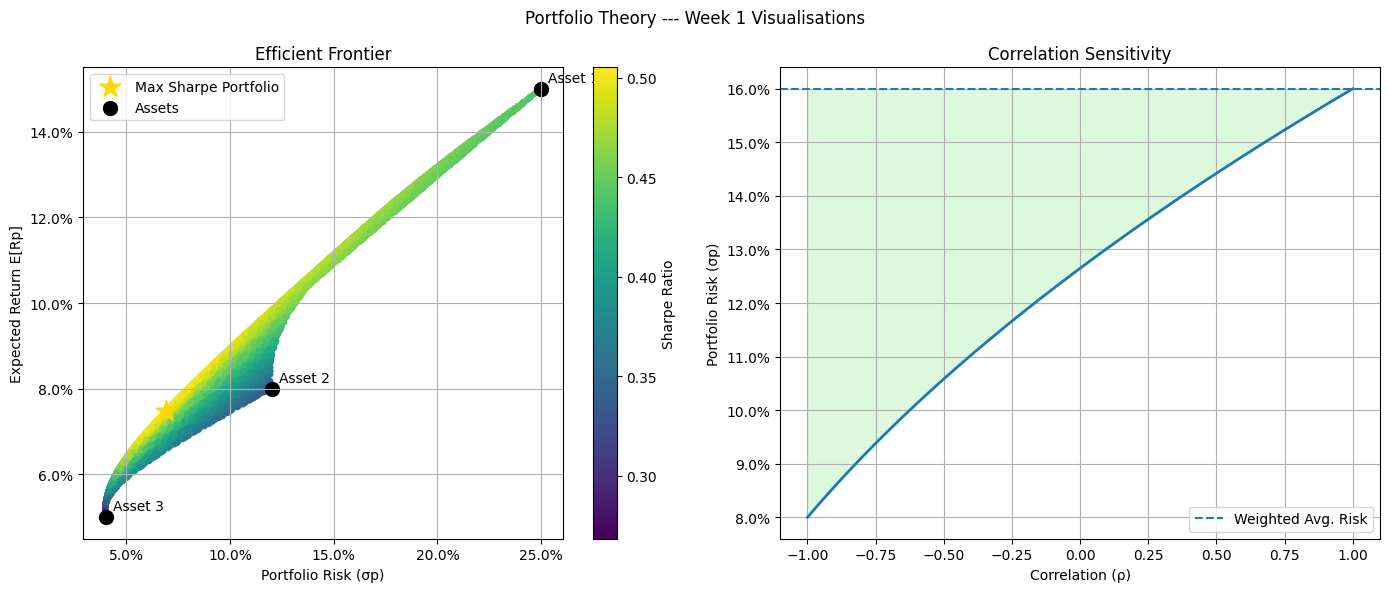

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

mu = np.array([0.15, 0.08, 0.05])

Sigma = np.array([
    [0.0625, 0.012,   0.001],
    [0.012,  0.0144,  0.00096],
    [0.001,  0.00096, 0.0016]
])

asset_labels = ['Asset 1', 'Asset 2', 'Asset 3']

asset_risks = np.sqrt(np.diag(Sigma))

Rf = 0.04

np.random.seed(0)

weights = np.random.dirichlet(np.ones(3), size=20000)

portfolio_returns = weights @ mu

portfolio_variances = np.sum((weights @ Sigma) * weights, axis=1)

portfolio_std = np.sqrt(portfolio_variances)

sharpe_ratios = (portfolio_returns - Rf) / portfolio_std

max_index = np.argmax(sharpe_ratios)

max_return = portfolio_returns[max_index]

max_std = portfolio_std[max_index]

mu1 = 0.12
sigma1 = 0.20

mu2 = 0.06
sigma2 = 0.10

w1 = 0.6
w2 = 0.4

rho = np.linspace(-1, 1, 200)

portfolio_variance_2 = (
    (w1**2) * (sigma1**2)
    + (w2**2) * (sigma2**2)
    + 2 * w1 * w2 * rho * sigma1 * sigma2
)

portfolio_std_2 = np.sqrt(portfolio_variance_2)

weighted_avg_risk = w1 * sigma1 + w2 * sigma2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter = axes[0].scatter(
    portfolio_std,
    portfolio_returns,
    c=sharpe_ratios,
    cmap='viridis',
    s=10
)

axes[0].scatter(
    max_std,
    max_return,
    marker='*',
    s=250,
    color='gold',
    label='Max Sharpe Portfolio'
)

axes[0].scatter(
    asset_risks,
    mu,
    color='black',
    s=100,
    label='Assets'
)

for i in range(len(asset_labels)):
    axes[0].annotate(
        asset_labels[i],
        (asset_risks[i], mu[i]),
        textcoords="offset points",
        xytext=(5,5)
    )

axes[0].set_title('Efficient Frontier')

axes[0].set_xlabel('Portfolio Risk (σp)')

axes[0].set_ylabel('Expected Return E[Rp]')

axes[0].xaxis.set_major_formatter(PercentFormatter(1))

axes[0].yaxis.set_major_formatter(PercentFormatter(1))

axes[0].grid(True)

axes[0].legend()

cbar = fig.colorbar(scatter, ax=axes[0])

cbar.set_label('Sharpe Ratio')

axes[1].plot(
    rho,
    portfolio_std_2,
    linewidth=2
)

axes[1].axhline(
    weighted_avg_risk,
    linestyle='--',
    label='Weighted Avg. Risk'
)

axes[1].fill_between(
    rho,
    portfolio_std_2,
    weighted_avg_risk,
    where=(portfolio_std_2 < weighted_avg_risk),
    alpha=0.3,
    color='lightgreen'
)

axes[1].set_title('Correlation Sensitivity')

axes[1].set_xlabel('Correlation (ρ)')

axes[1].set_ylabel('Portfolio Risk (σp)')

axes[1].yaxis.set_major_formatter(PercentFormatter(1))

axes[1].grid(True)

axes[1].legend()

plt.suptitle('Portfolio Theory --- Week 1 Visualisations')

plt.tight_layout()

plt.savefig('week1_plots.png', dpi=150)

plt.show()